# Supplementary Figure 1: Parallel-Coordinates Hyperparameter Search

This notebook creates a condensed parallel-coordinates representation of the Optuna hyperparameter-search results used for the manuscript. It reads the existing `optuna_search_results.csv` file and saves the figure as SVG, PDF, and PNG outputs in the `FIGURES` folder.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.lines import Line2D

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

ROOT = Path.cwd()
FIGURE_DIR = ROOT / 'FIGURES'
FIGURE_DIR.mkdir(exist_ok=True)

candidate_csvs = [
    ROOT / 'hyperparameter_search_by_size' / 'optuna_search_results_16000.csv',
    ROOT / 'hyperparameter_search_by_size' / 'optuna_search_results_all_sizes.csv',
    ROOT / 'optuna_search_results.csv',
]

for csv_path in candidate_csvs:
    if csv_path.exists():
        break
else:
    raise FileNotFoundError('Could not find an Optuna trial-history CSV file.')

df_raw = pd.read_csv(csv_path)
print(f'Loaded {len(df_raw):,} trials from {csv_path.relative_to(ROOT)}')

Loaded 500 trials from optuna_search_results.csv


In [4]:
csv_path

PosixPath('/Users/serhiibahdasariants/Desktop/ANNet/optuna_search_results.csv')

In [2]:
def prepare_trials(df):
    df_plot = df.copy()
    if 'RMSE' not in df_plot.columns:
        df_plot['RMSE'] = np.sqrt(df_plot['value'])
    df_plot = df_plot[np.isfinite(df_plot['RMSE'])].copy()

    activation_order = ['Tanh', 'Softplus', 'ReLU', 'ELU', 'GELU']
    activation_to_code = {name: i for i, name in enumerate(activation_order)}
    df_plot['activation_code'] = df_plot['params_activation'].map(activation_to_code)

    for layer_idx in range(10):
        col = f'params_n_units_l{layer_idx}'
        if col not in df_plot.columns:
            df_plot[col] = np.nan
        # Optuna only reports width parameters for layers that exist in a trial.
        # Encoding absent deeper layers as 0 makes shallow and deep architectures
        # visible on the same parallel-coordinates axis family.
        df_plot[col] = df_plot[col].fillna(0)

    return df_plot, activation_order


df_plot, activation_order = prepare_trials(df_raw)
best_idx = df_plot['RMSE'].idxmin()
best_row = df_plot.loc[best_idx]
top_decile_cutoff = df_plot['RMSE'].quantile(0.10)

print(f'Best trial: #{int(best_row["number"])}')
print(f'Best RMSE: {best_row["RMSE"]:.4f} N m')
print(f'Best activation: {best_row["params_activation"]}')
print(f'Best learning rate: {best_row["params_lr"]:.4g}')
print(f'Best depth: {int(best_row["params_n_layers"])} hidden layers')

Best trial: #220
Best RMSE: 0.2164 N m
Best activation: GELU
Best learning rate: 0.001132
Best depth: 4 hidden layers


Saved FIGURES/FIG S1.svg
Saved FIGURES/FIG S1.pdf
Saved FIGURES/FIG S1.png


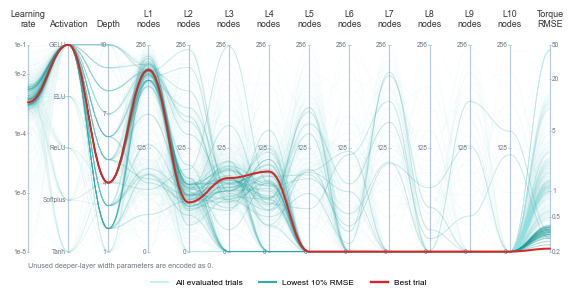

In [5]:
def log_norm(values, vmin, vmax):
    values = np.asarray(values, dtype=float)
    values = np.clip(values, vmin, vmax)
    return (np.log10(values) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin))


def linear_norm(values, vmin, vmax):
    values = np.asarray(values, dtype=float)
    return (values - vmin) / (vmax - vmin)


def add_smooth_polyline(ax, xs, ys, color, alpha, linewidth, zorder):
    vertices = [(xs[0], ys[0])]
    codes = [MplPath.MOVETO]
    for i in range(len(xs) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i + 1], ys[i + 1]
        dx = x1 - x0
        vertices.extend([
            (x0 + 0.42 * dx, y0),
            (x1 - 0.42 * dx, y1),
            (x1, y1),
        ])
        codes.extend([MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4])
    patch = PathPatch(
        MplPath(vertices, codes),
        facecolor='none',
        edgecolor=color,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder,
        capstyle='round',
        joinstyle='round',
    )
    ax.add_patch(patch)


dimensions = [
    {
        'column': 'params_lr',
        'label': 'Learning\nrate',
        'norm': lambda s: log_norm(s, 1e-8, 1e-1),
        'ticks': [1e-8, 1e-6, 1e-4, 1e-2, 1e-1],
        'ticklabels': ['1e-8', '1e-6', '1e-4', '1e-2', '1e-1'],
        'ticknorm': lambda v: log_norm(v, 1e-8, 1e-1),
    },
    {
        'column': 'activation_code',
        'label': 'Activation',
        'norm': lambda s: linear_norm(s, 0, len(activation_order) - 1),
        'ticks': list(range(len(activation_order))),
        'ticklabels': activation_order,
        'ticknorm': lambda v: linear_norm(v, 0, len(activation_order) - 1),
    },
    {
        'column': 'params_n_layers',
        'label': 'Depth',
        'norm': lambda s: linear_norm(s, 1, 10),
        'ticks': [1, 4, 7, 10],
        'ticklabels': ['1', '4', '7', '10'],
        'ticknorm': lambda v: linear_norm(v, 1, 10),
    },
]

for layer_idx in range(10):
    dimensions.append({
        'column': f'params_n_units_l{layer_idx}',
        'label': f'L{layer_idx + 1}\nnodes',
        'norm': lambda s, vmin=0, vmax=256: linear_norm(s, vmin, vmax),
        'ticks': [0, 128, 256],
        'ticklabels': ['0', '128', '256'],
        'ticknorm': lambda v, vmin=0, vmax=256: linear_norm(v, vmin, vmax),
    })

rmse_max = max(50.0, float(np.nanmax(df_plot['RMSE'])))
dimensions.append({
    'column': 'RMSE',
    'label': 'Torque\nRMSE',
    'norm': lambda s: log_norm(s, 0.2, rmse_max),
    'ticks': [0.2, 0.5, 1, 5, 20, rmse_max],
    'ticklabels': ['0.2', '0.5', '1', '5', '20', f'{rmse_max:g}'],
    'ticknorm': lambda v: log_norm(v, 0.2, rmse_max),
})

x_positions = np.arange(len(dimensions), dtype=float)
y_columns = [dim['norm'](df_plot[dim['column']].to_numpy()) for dim in dimensions]
y_matrix = np.vstack(y_columns).T

fig, ax = plt.subplots(figsize=(7.2, 3.25))
ax.set_xlim(-0.45, len(dimensions) - 0.55)
ax.set_ylim(-0.08, 1.13)
ax.axis('off')

axis_color = '#B7C9D9'
tick_color = '#6F7780'
label_color = '#333333'

for x, dim in zip(x_positions, dimensions):
    ax.plot([x, x], [0, 1], color=axis_color, linewidth=0.85, zorder=1)
    ax.text(x, 1.075, dim['label'], ha='center', va='bottom', color=label_color, fontsize=6.4)
    for tick, ticklabel in zip(dim['ticks'], dim['ticklabels']):
        y = float(dim['ticknorm']([tick])[0])
        if 0 <= y <= 1:
            ax.plot([x - 0.035, x + 0.035], [y, y], color=axis_color, linewidth=0.55, zorder=2)
            horizontal_offset = -0.055 if x < len(dimensions) - 1 else 0.055
            align = 'right' if x < len(dimensions) - 1 else 'left'
            ax.text(x + horizontal_offset, y, ticklabel, ha=align, va='center', color=tick_color, fontsize=4.7)

df_ordered = df_plot.sort_values('RMSE', ascending=False)
for row_idx, row in df_ordered.iterrows():
    ys = y_matrix[df_plot.index.get_loc(row_idx)]
    if row_idx == best_idx:
        continue
    if row['RMSE'] <= top_decile_cutoff:
        color, alpha, linewidth, zorder = '#209E9B', 0.22, 0.72, 5
    else:
        color, alpha, linewidth, zorder = '#8EDFE0', 0.075, 0.42, 3
    add_smooth_polyline(ax, x_positions, ys, color, alpha, linewidth, zorder)

best_ys = y_matrix[df_plot.index.get_loc(best_idx)]
add_smooth_polyline(ax, x_positions, best_ys, '#D62728', 1.0, 1.45, 9)

legend_handles = [
    Line2D([0], [0], color='#8EDFE0', lw=1.2, alpha=0.55, label='All evaluated trials'),
    Line2D([0], [0], color='#209E9B', lw=1.5, alpha=0.9, label='Lowest 10% RMSE'),
    Line2D([0], [0], color='#D62728', lw=1.7, label='Best trial'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.10), ncol=3, frameon=False)
ax.text(0, -0.055, 'Unused deeper-layer width parameters are encoded as 0.', ha='left', va='top', color=tick_color, fontsize=5.2)

output_base = FIGURE_DIR / 'FIG S1'
fig.savefig(output_base.with_suffix('.svg'), format='svg', bbox_inches='tight', pad_inches=0.025)
fig.savefig(output_base.with_suffix('.pdf'), bbox_inches='tight', pad_inches=0.025)
fig.savefig(output_base.with_suffix('.png'), dpi=600, bbox_inches='tight', pad_inches=0.025)
print(f'Saved {output_base.with_suffix(".svg").relative_to(ROOT)}')
print(f'Saved {output_base.with_suffix(".pdf").relative_to(ROOT)}')
print(f'Saved {output_base.with_suffix(".png").relative_to(ROOT)}')
plt.show()